
# Lab 5: FDM difussion equation

Santiago Andrés Angulo Toro CC 1001154362

 **Exercise** : Solve the difussion eqution for the next system ... optional.

Heat diffusion in a plate

Consider the diffusion equation applied to a metal plate initially at temperature $T_\text{cold}$  apart from a disc of a specified size which is at temperature $T_\text{hot}$. We suppose that the edges of the plate are held fixed at $T_\text{cold}$. The following code applies the above formula to follow the evolution of the temperature of the plate.

.... see

The state of the system is plotted as an image at four different stages of its evolution.

Taken from: https://scipython.com/books/book2/chapter-7-matplotlib/examples/the-two-dimensional-diffusion-equation/


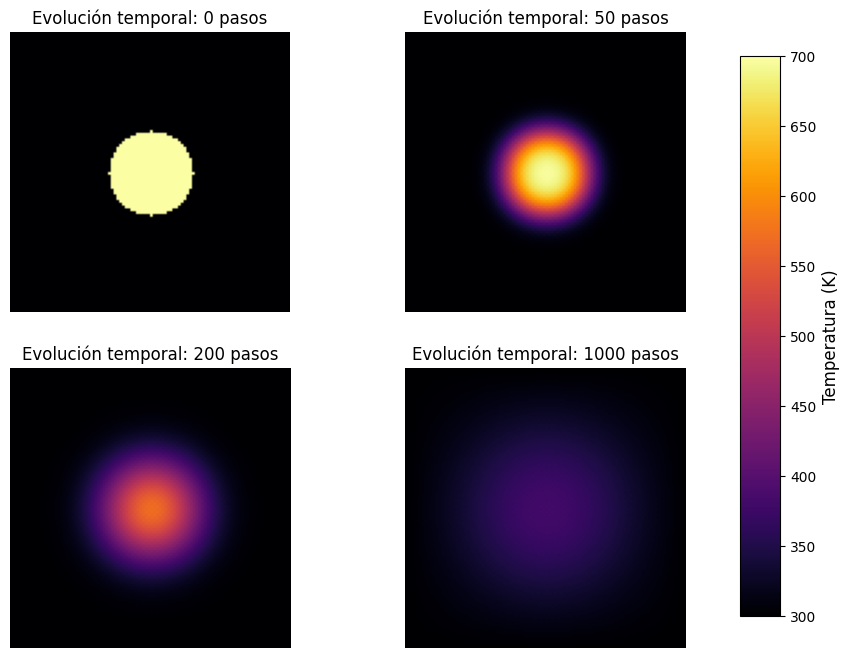

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parámetros físicos y de la malla
w, h = 100, 100        # Dimensiones de la malla (100x100)
dx = 1.0               # Paso espacial (ej. mm)
alpha = 4.0            # Difusividad térmica del material
dt = (dx**2)/(4*alpha) # Paso temporal para garantizar estabilidad (gamma = 0.25)
gamma = (alpha * dt) / (dx**2)

T_cold = 300.0         # Temperatura de la placa y fronteras
T_hot = 700.0          # Temperatura del disco central

# 2. Condiciones Iniciales y de Frontera
# Inicializo toda la placa fría
T = np.full((h, w), T_cold)

# Creo el disco caliente en el centro
radio = 15.0
centro_x, centro_y = w // 2, h // 2

for i in range(h):
    for j in range(w):
        if (i - centro_y)**2 + (j - centro_x)**2 <= radio**2:
            T[i, j] = T_hot

# 3. Función de evolución temporal

def evolucionar_temperatura(T):
    # Creo una copia para el siguiente paso (preservando las fronteras frías)
    T_nuevo = T.copy()

    # Aplico la fórmula FDM en todos los puntos interiores simultáneamente
    T_nuevo[1:-1, 1:-1] = T[1:-1, 1:-1] + gamma * (
        T[2:, 1:-1] + T[:-2, 1:-1] + T[1:-1, 2:] + T[1:-1, :-2] - 4 * T[1:-1, 1:-1]
    )
    return T_nuevo

# 4. Simulación y Visualización
pasos_grafica = [0, 50, 200, 1000]
max_pasos = max(pasos_grafica) + 1

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
indice_plot = 0

for step in range(max_pasos):
    if step in pasos_grafica:
        ax = axes[indice_plot]
        im = ax.imshow(T, cmap='inferno', vmin=T_cold, vmax=T_hot)
        ax.set_title(f'Evolución temporal: {step} pasos')
        ax.axis('off')
        indice_plot += 1

    T = evolucionar_temperatura(T)

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.04, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Temperatura (K)', fontsize=12)

plt.show()